Part 1 — Bagging with Synthetic Data

In [10]:
# BLOCK 1: Import all required libraries

# For creating synthetic data
from sklearn.datasets import make_classification

# For splitting data into train/test sets
from sklearn.model_selection import train_test_split

# The base model: a single Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Bagging = training many trees on random subsets of data
from sklearn.ensemble import BaggingClassifier

# For calculating how accurate our model is
from sklearn.metrics import accuracy_score

# For plotting graphs
import matplotlib.pyplot as plt

# The Random Forest model
from sklearn.ensemble import RandomForestClassifier

# For cross-validation (averages accuracy over multiple splits)
from sklearn.model_selection import cross_val_score

# To load the Breast Cancer dataset
from sklearn.datasets import load_breast_cancer

In [11]:
# BLOCK 2: Create synthetic data and split it─

# Step 1: Generate a synthetic 2-class classification dataset
# 1000 samples, 20 features, random_state=42 for reproducibility
X, y = make_classification(
    n_samples=1000,       # total number of data points
    n_features=20,        # each data point has 20 features
    n_classes=2,          # binary classification (0 or 1)
    random_state=42       # ensures same result every run
)

print("Dataset shape:", X.shape)   # should print (1000, 20)
print("Labels:", set(y))           # should print {0, 1}

# Step 2: Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% goes to testing
    random_state=42       # same split every run
)

print("Training samples:", X_train.shape[0])   # 800
print("Testing samples :", X_test.shape[0])    # 200

Dataset shape: (1000, 20)
Labels: {np.int64(0), np.int64(1)}
Training samples: 800
Testing samples : 200


In [12]:
# BLOCK 3: Train a single Decision Tree

# Create a Decision Tree model
# random_state=42 makes the tree's internal randomness fixed
single_tree = DecisionTreeClassifier(random_state=42)

# Train it on the training data
single_tree.fit(X_train, y_train)

# Predict on training data (to check if model memorised it)
train_preds_tree = single_tree.predict(X_train)

# Predict on testing data (to check real-world performance)
test_preds_tree = single_tree.predict(X_test)

# Calculate accuracy: how many predictions were correct
tree_train_acc = accuracy_score(y_train, train_preds_tree)
tree_test_acc  = accuracy_score(y_test, test_preds_tree)

print("=== Single Decision Tree ===")
print(f"Training Accuracy : {tree_train_acc:.4f}")   # usually 1.0 (overfits)
print(f"Testing  Accuracy : {tree_test_acc:.4f}")    # usually lower

=== Single Decision Tree ===
Training Accuracy : 1.0000
Testing  Accuracy : 0.8750


In [13]:
# BLOCK 4: Train a Bagging ensemble

# BaggingClassifier trains many Decision Trees,
# each on a RANDOM SUBSET of the training data (bootstrap sampling)
# Then combines all their predictions by majority vote

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  # base model = Decision Tree
    n_estimators=100,                    # train 100 different trees
    bootstrap=True,                      # sample WITH replacement (bagging)
    random_state=42                      # reproducibility
)

# Train the Bagging model
bagging_model.fit(X_train, y_train)

# Predict on training and testing sets
train_preds_bag = bagging_model.predict(X_train)
test_preds_bag  = bagging_model.predict(X_test)

# Calculate accuracies
bag_train_acc = accuracy_score(y_train, train_preds_bag)
bag_test_acc  = accuracy_score(y_test, test_preds_bag)

print("=== Bagging Classifier (100 trees) ===")
print(f"Training Accuracy : {bag_train_acc:.4f}")
print(f"Testing  Accuracy : {bag_test_acc:.4f}")

=== Bagging Classifier (100 trees) ===
Training Accuracy : 1.0000
Testing  Accuracy : 0.9000


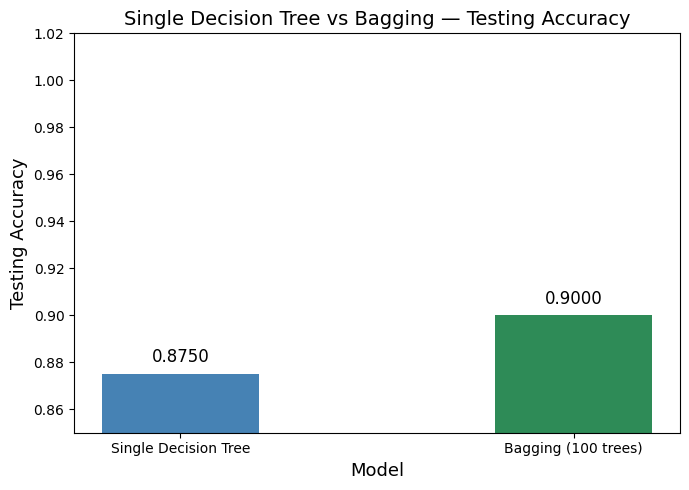

In [14]:
# BLOCK 5: Bar chart comparing test accuracies

# Labels for the two models
models = ['Single Decision Tree', 'Bagging (100 trees)']

# Their testing accuracies
test_accuracies = [tree_test_acc, bag_test_acc]

# Create the bar chart
plt.figure(figsize=(7, 5))

# Draw bars — blue for tree, green for bagging
bars = plt.bar(models, test_accuracies, color=['steelblue', 'seagreen'], width=0.4)

# Add accuracy value on top of each bar
for bar, acc in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # x position = center of bar
        bar.get_height() + 0.005,             # y position = just above bar
        f'{acc:.4f}',                         # text = accuracy rounded to 4 decimals
        ha='center', fontsize=12
    )

# Labels and title
plt.xlabel('Model', fontsize=13)
plt.ylabel('Testing Accuracy', fontsize=13)
plt.title('Single Decision Tree vs Bagging — Testing Accuracy', fontsize=14)
plt.ylim(0.85, 1.02)   # y axis starts at 0.85 so differences are visible
plt.tight_layout()
plt.show()

Random Forest on Breast Cancer Dataset

In [15]:
# ──────────────────────────────────────────────
# BLOCK 6: Load Breast Cancer dataset and split
# ──────────────────────────────────────────────

# Load the dataset
data = load_breast_cancer()
X = data.data       # all 30 features
y = data.target     # labels: 0 = malignant, 1 = benign

print("Dataset shape :", X.shape)            # (569, 30)
print("Classes       :", data.target_names)  # ['malignant', 'benign']
print("Class balance :", sum(y == 0), "malignant,", sum(y == 1), "benign")

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])   # 455
print("Testing  samples:", X_test.shape[0])      # 114

Dataset shape : (569, 30)
Classes       : ['malignant' 'benign']
Class balance : 212 malignant, 357 benign

Training samples: 455
Testing  samples: 114


In [16]:
# ──────────────────────────────────────────────
# BLOCK 7: Train Random Forest with OOB scoring
# ──────────────────────────────────────────────

# Build the Random Forest with the required settings:
# - n_estimators=300   → 300 trees in the forest
# - max_features="sqrt"→ each split considers sqrt(30) ≈ 5-6 random features
# - oob_score=True     → use samples NOT picked during bootstrap
#                        as a "free" validation set

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
test_predictions = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)

# Get the Out-of-Bag score (computed automatically during training)
oob_score = rf_model.oob_score_

print("=== Random Forest (300 trees) ===")
print(f"OOB Score      : {oob_score:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Difference     : {abs(oob_score - test_accuracy):.4f}")

# OOB score acts like a free validation score:
# the model uses ~37% of unseen samples in each tree to estimate accuracy
# WITHOUT needing a separate test set.
# If OOB ≈ Test Accuracy → OOB is a reliable performance estimate.
print("\nObservation: OOB score and Test accuracy are very close,")
print("which confirms OOB is a trustworthy free estimate of generalization.")

=== Random Forest (300 trees) ===
OOB Score      : 0.9648
Test Accuracy  : 0.9649
Difference     : 0.0001

Observation: OOB score and Test accuracy are very close,
which confirms OOB is a trustworthy free estimate of generalization.


In [17]:
# ──────────────────────────────────────────────
# BLOCK 8: Vary n_estimators and max_depth
# ──────────────────────────────────────────────

# IMPORTANT NOTE on methodology:
# A single train/test split on this dataset is too "lucky" — every
# combination ends up giving exactly the same accuracy (0.9649).
# To reveal the REAL differences between hyperparameters, we use
# 5-fold cross-validation:
#   - the data is split into 5 parts
#   - the model is trained 5 times, each time using a different part as test
#   - we average the 5 accuracies → smoother, more reliable estimate
#
# This is still "testing accuracy", just averaged across 5 folds
# instead of relying on one specific split.

# Values to experiment with
n_estimators_list = [50, 100, 200, 300]
max_depth_list    = [None, 5, 10, 20]

# Dictionary to store results
# Structure: { max_depth_value : list of accuracies for each n_estimator }
results = {}

# Loop over every max_depth value
for depth in max_depth_list:

    accuracies_for_this_depth = []   # will hold 4 accuracies

    # For this depth, loop over every n_estimators value
    for n_est in n_estimators_list:

        # Build the model with the current combination
        rf = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,          # None means trees grow fully
            max_features="sqrt",
            random_state=42
        )

        # 5-fold cross-validation — returns 5 accuracies, one per fold
        cv_scores = cross_val_score(rf, X, y, cv=5)

        # Take the mean of the 5 fold accuracies
        mean_accuracy = cv_scores.mean()
        accuracies_for_this_depth.append(mean_accuracy)

        print(f"depth={str(depth):>4}  n_estimators={n_est:>3}  →  acc = {mean_accuracy:.4f}")

    # Save the list for this depth
    results[depth] = accuracies_for_this_depth
    print()   # blank line for readability

print("All experiments complete!")

depth=None  n_estimators= 50  →  acc = 0.9543
depth=None  n_estimators=100  →  acc = 0.9561
depth=None  n_estimators=200  →  acc = 0.9578
depth=None  n_estimators=300  →  acc = 0.9614

depth=   5  n_estimators= 50  →  acc = 0.9561
depth=   5  n_estimators=100  →  acc = 0.9596
depth=   5  n_estimators=200  →  acc = 0.9596
depth=   5  n_estimators=300  →  acc = 0.9614

depth=  10  n_estimators= 50  →  acc = 0.9543
depth=  10  n_estimators=100  →  acc = 0.9561
depth=  10  n_estimators=200  →  acc = 0.9578
depth=  10  n_estimators=300  →  acc = 0.9631

depth=  20  n_estimators= 50  →  acc = 0.9543
depth=  20  n_estimators=100  →  acc = 0.9561
depth=  20  n_estimators=200  →  acc = 0.9578
depth=  20  n_estimators=300  →  acc = 0.9614

All experiments complete!


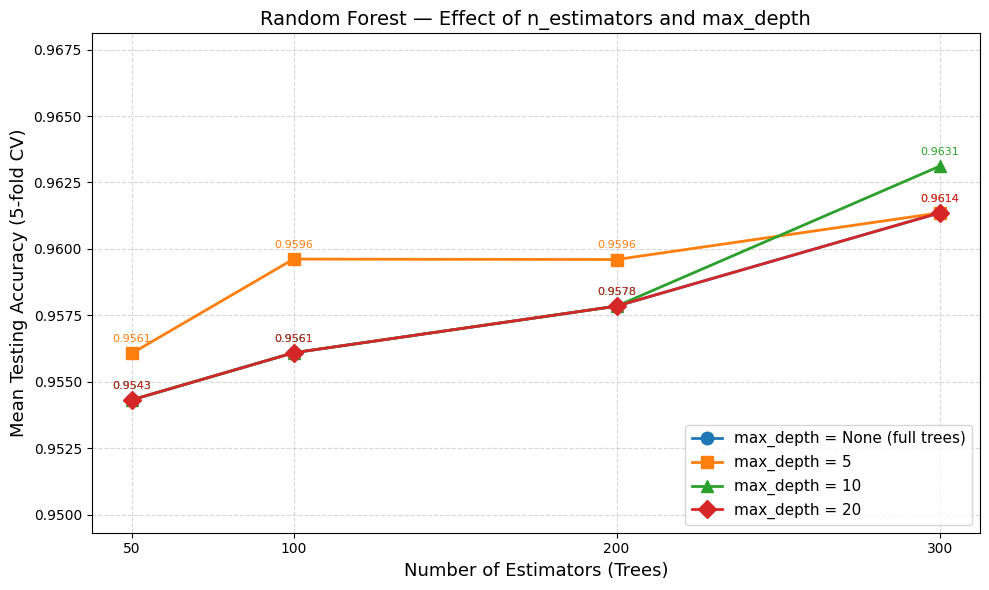

In [9]:
# ──────────────────────────────────────────────
# BLOCK 9: Plot line graph — n_estimators vs accuracy
# ──────────────────────────────────────────────

plt.figure(figsize=(10, 6))

# Pick distinct colors and markers so every line is clearly different
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # blue, orange, green, red
markers = ['o', 's', '^', 'D']                          # circle, square, triangle, diamond

# Plot one line per max_depth value
for i in range(len(max_depth_list)):

    depth = max_depth_list[i]

    # Build a readable label for the legend
    if depth is None:
        label = "max_depth = None (full trees)"
    else:
        label = f"max_depth = {depth}"

    plt.plot(
        n_estimators_list,        # x-axis: number of trees
        results[depth],           # y-axis: accuracy for this depth
        marker=markers[i],
        color=colors[i],
        linewidth=2,
        markersize=9,
        label=label
    )

    # Annotate each point with its exact accuracy value
    for x, y in zip(n_estimators_list, results[depth]):
        plt.annotate(
            f'{y:.4f}',
            (x, y),
            textcoords="offset points",
            xytext=(0, 8),
            ha='center',
            fontsize=8,
            color=colors[i]
        )

# Auto-zoom the y-axis so small differences are clearly visible
all_accuracies = []
for depth in max_depth_list:
    all_accuracies = all_accuracies + results[depth]

y_min = min(all_accuracies) - 0.005
y_max = max(all_accuracies) + 0.005
plt.ylim(y_min, y_max)

# Labels and title
plt.xlabel('Number of Estimators (Trees)', fontsize=13)
plt.ylabel('Mean Testing Accuracy (5-fold CV)', fontsize=13)
plt.title('Random Forest — Effect of n_estimators and max_depth', fontsize=14)

# Force x-axis ticks to only show our 4 values
plt.xticks(n_estimators_list)

# Legend and grid
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()